<a href="https://colab.research.google.com/github/hudsonshank/AI-Executive-Board/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, let's upload the dataset. **Please be sure to edit the file path to reflect the file path on your own drive.**

*For teammates - I would suggest creating a new folder in your drive titled "COMP560 FINAL PROJECT CODE". Then, create a shortcut from the CSV in our shared file to your that folder in your drive.*

In [ ]:
# prompt: upload the file from the same folder in google drive

from google.colab import drive
drive.mount('/content/drive')


import pandas as pd

file_path = '/content/drive/My Drive/COMP560 FINAL PROJECT CODE/Copy of CA_Weather_Fire_Dataset_1984-2025.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Preview it
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


We need to clean some of the data. Namely:
1. FIRE_START_DAY - ensure it is in 0's and 1's instead of true/false
2. SEASON - Categorical variable.
3. DATE - Split it up into numerical year and month (since day is coded into DAY_OF_YEAR)


In [ ]:
# prompt: FIRE_START_DAY - ensure it is in 0's and 1's instead of true/false

df['FIRE_START_DAY'] = df['FIRE_START_DAY'].astype(int)


In [ ]:
# prompt: 2. SEASON is Categorical variable change it to numericals. there exist 4 seasons

# Create a mapping for seasons to numerical values
season_mapping = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}

# Apply the mapping to the 'SEASON' column
df['SEASON'] = df['SEASON'].map(season_mapping)

# Now 'SEASON' column contains numerical representations of seasons.


In [ ]:
import pandas as pd
# Convert 'DATE' column to datetime objects
df['DATE'] = pd.to_datetime(df['DATE'])

# Extract month and year
df['MONTH'] = df['DATE'].dt.month
df['YEAR'] = df['DATE'].dt.year
df['DAY_OF_MONTH'] = df['DATE'].dt.day

# Drop the original 'DATE' column
df = df.drop('DATE', axis=1)


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14988 entries, 0 to 14987
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PRECIPITATION          14987 non-null  float64
 1   MAX_TEMP               14987 non-null  float64
 2   MIN_TEMP               14987 non-null  float64
 3   AVG_WIND_SPEED         14976 non-null  float64
 4   FIRE_START_DAY         14988 non-null  int64  
 5   YEAR                   14988 non-null  int32  
 6   TEMP_RANGE             14987 non-null  float64
 7   WIND_TEMP_RATIO        14976 non-null  float64
 8   MONTH                  14988 non-null  int32  
 9   SEASON                 14988 non-null  int64  
 10  LAGGED_PRECIPITATION   14988 non-null  float64
 11  LAGGED_AVG_WIND_SPEED  14988 non-null  float64
 12  DAY_OF_YEAR            14988 non-null  int64  
 13  DAY_OF_MONTH           14988 non-null  int32  
dtypes: float64(8), int32(3), int64(3)
memory usage: 1.4 MB

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,DAY_OF_MONTH
0,0.0,79.0,51.0,4.70,0,1984,28.0,0.059494,1,0,0.0,4.700,1,1
1,0.0,71.0,46.0,5.59,0,1984,25.0,0.078732,1,0,0.0,5.145,2,2
2,0.0,70.0,47.0,5.37,0,1984,23.0,0.076714,1,0,0.0,5.220,3,3
3,0.0,76.0,45.0,4.70,0,1984,31.0,0.061842,1,0,0.0,5.090,4,4
4,0.0,74.0,49.0,5.14,0,1984,25.0,0.069459,1,0,0.0,5.100,5,5


1. Check for class imabalance. Since "fires" are less common than "non-fires", the dataset and resulting model will have an inherent bias for classifying "fires". We can check this and rectify it by rebalancing the dataset.

In [ ]:
df['FIRE_START_DAY'].value_counts(normalize=True)


,proportion
FIRE_START_DAY,
0,0.668335
1,0.331665


While the dataset shows a moderate imbalance (fire days = 33.2%, no-fire = 66.8%), this is not extreme. To mitigate potential bias, models will be trained using class-weighted loss functions and evaluated using F1-score and recall to better capture fire-start events.

Finding the Pearson correlation between each feature and teh binary target (FIRE_START_DAY) to show each feature's linear corrleation strength.

MIN_TEMP                 0.468037
MAX_TEMP                 0.368320
SEASON                   0.306868
LAGGED_PRECIPITATION    -0.214150
MONTH                    0.143713
DAY_OF_YEAR              0.141905
YEAR                     0.120610
PRECIPITATION           -0.115607
WIND_TEMP_RATIO         -0.093606
TEMP_RANGE              -0.082107
LAGGED_AVG_WIND_SPEED    0.077318
AVG_WIND_SPEED           0.031216
DAY_OF_MONTH             0.000119
Name: FIRE_START_DAY, dtype: float64


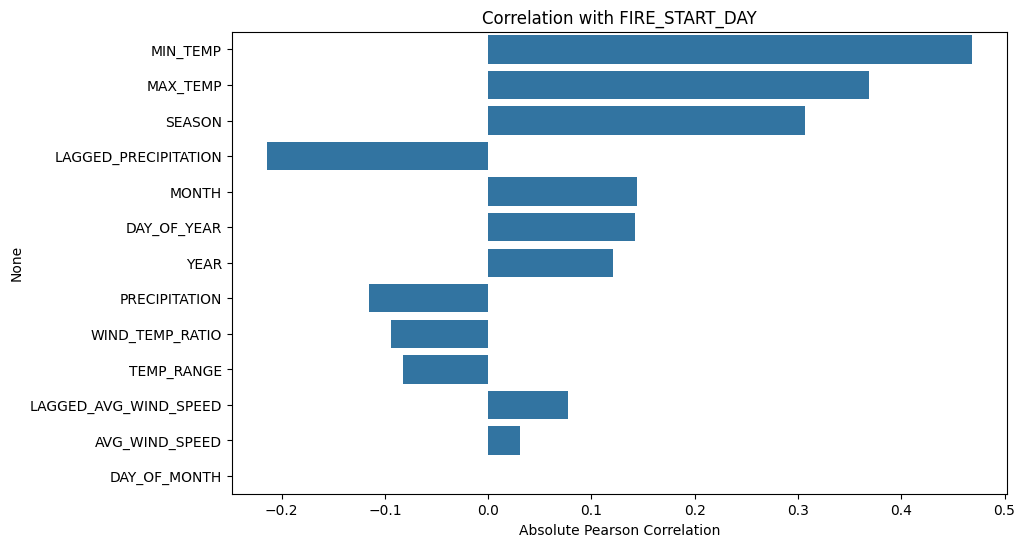

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop the target itself for the correlation display
correlation = df.corr(numeric_only=True)['FIRE_START_DAY'].drop('FIRE_START_DAY').sort_values(key=abs, ascending=False)

print(correlation)

plt.figure(figsize=(10,6))
sns.barplot(x=correlation.values, y=correlation.index)
plt.title('Correlation with FIRE_START_DAY')
plt.xlabel('Absolute Pearson Correlation')
plt.show()


We see that MIN_TEMP, MAX_TEMP, and SEASON are the most linearly predictive variables (as they are the TOP 3 features of the chart). They are all positively correlated with the occurence of a fire. Now we have to investigate non-linear correlations and patterns.

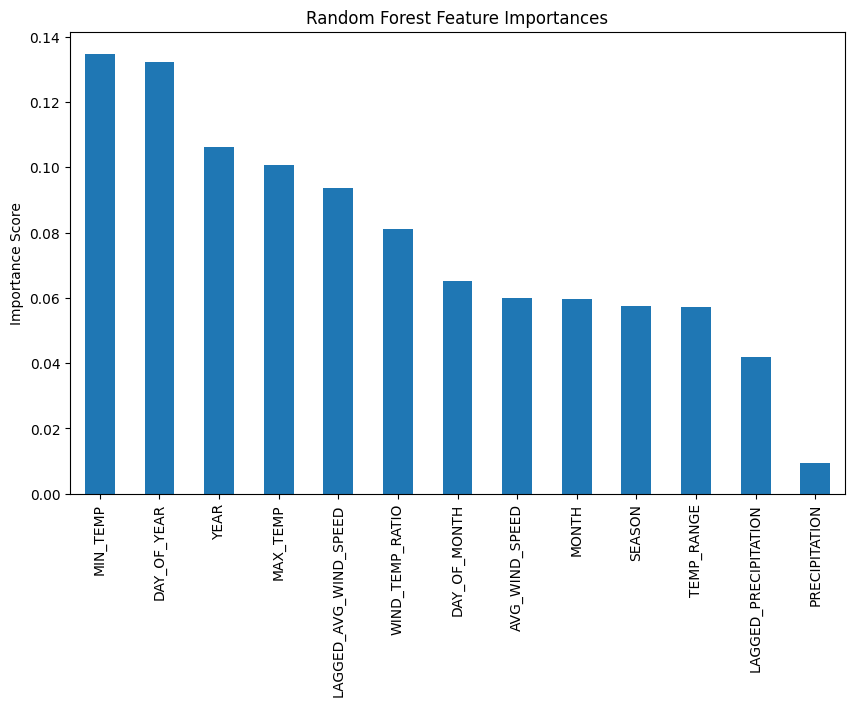

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['FIRE_START_DAY'])
y = df['FIRE_START_DAY']

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Random Forest Feature Importances')
plt.ylabel('Importance Score')
plt.show()


We see that MIN_TEMP and MAX_TEMP are still in the top 3 features for predicting fire starts. Instead of SEASON, we've now identified DAY_OF_THE_YEAR as a top 3 correlation between fire starts.

Other strongly correlated features are "YEAR" which is suprising because year itself does not represent any physical weather condition. It might be picking up long-term changes in climate or reporting patterns over time.

Unlike in the correlation plot, DAY_OF_YEAR, WIND_TEMP_RATIO, and LAGGED_AVG_WIND_SPEED were more important here.

PRECIPITATION, which had moderate negative correlation, was least useful to the model (likely due to redundancy with LAGGED_PRECIPITATION or lower variance).

**Dimensonality Reduction for Feature Selection with Principal Component Analysis (PCA) and t-SNE**

# Applying PCA

The dataset contained fewer than 0.02% missing values across all columns. Given the small fraction, we dropped these rows to keep the pipeline clean and compatible with dimensionality reduction techniques like PCA and t-SNE. This ensures downstream steps remain robust and interpretable without requiring us to consider which imputation method we should choose.

*Standardizing features since PCA and t-SNE are both sensitive to scale. By standardizing we can ensure all features are weighed equally when reducing the dimensionality of this dataset.*

In [ ]:
# Drop rows with any missing values
df_clean = df.dropna()

# Separate features and target again
X = df_clean.drop(columns=['FIRE_START_DAY'])
y = df_clean['FIRE_START_DAY']

# Scale for PCA/t-SNE
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)



Because our downstream modeling will use a neural network, we opted to scale features using MinMaxScaler, which rescales all variables into a [0, 1] range. This ensures that the network receives uniformly scaled inputs and avoids issues with gradient instability during training. While StandardScaler is typically preferred for PCA, the tradeoff is acceptable for maintaining consistency with our modeling pipeline.

PCA will tell us how many features are needed to explain 80-90% of the variance in our data. Instead of unnecssarily complicating our model, we want to choose the features that contribute the most variance so our final model is not too complicated to not function.

In [ ]:
# 1. Import PCA
from sklearn.decomposition import PCA

# 2. Instantiate the model
pca = PCA()

# 3. Fit the model
x_pca = pca.fit_transform(X_scaled)

# 4. Put the output in a dataframe
x_pca = pd.DataFrame(x_pca)

# 5. Let's see what the 6 principle components (PCs) look like
x_pca.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.854582,-0.398408,-0.493126,-0.183040,0.539965,0.008203,-0.143521,0.071951,0.062858,0.001495,0.005035,-5.840302e-07,-3.358425e-15
1,-0.888008,-0.352701,-0.498223,-0.200231,0.387836,-0.120303,-0.117453,0.085944,0.027934,0.000300,-0.004296,8.195820e-05,3.053113e-15
2,-0.883185,-0.323644,-0.493914,-0.179131,0.345197,-0.106996,-0.149212,0.068134,0.018872,0.001046,-0.003402,2.020660e-04,3.580469e-15
3,-0.877334,-0.284890,-0.487045,-0.211043,0.562727,-0.117374,-0.057198,0.071775,0.034746,0.006972,0.000434,-1.364864e-04,-1.526557e-15
4,-0.863283,-0.264760,-0.483390,-0.153161,0.425700,-0.049473,-0.144065,0.066449,0.035863,0.001525,-0.000530,1.754659e-04,1.443290e-15


Now let's see how much variance each principal component (PC) explains.

In [ ]:
# 6. Check Variance Explained
explained_variance = pca.explained_variance_ratio_
with np.printoptions(suppress=True, precision=4): # Suppressing scientific notation
    print(pca.explained_variance_ratio_)

[0.4447 0.1473 0.1425 0.1267 0.0597 0.03   0.0284 0.01   0.0088 0.0017
 0.0001 0.     0.    ]


Wow! So we see that the first PC accoutns for 30.16% variance, and second, third, fourth account for 20.90%, 12.77%, and 9.65%.


Let's plot the cumulative variance to see how many PCs we realy need for our model.



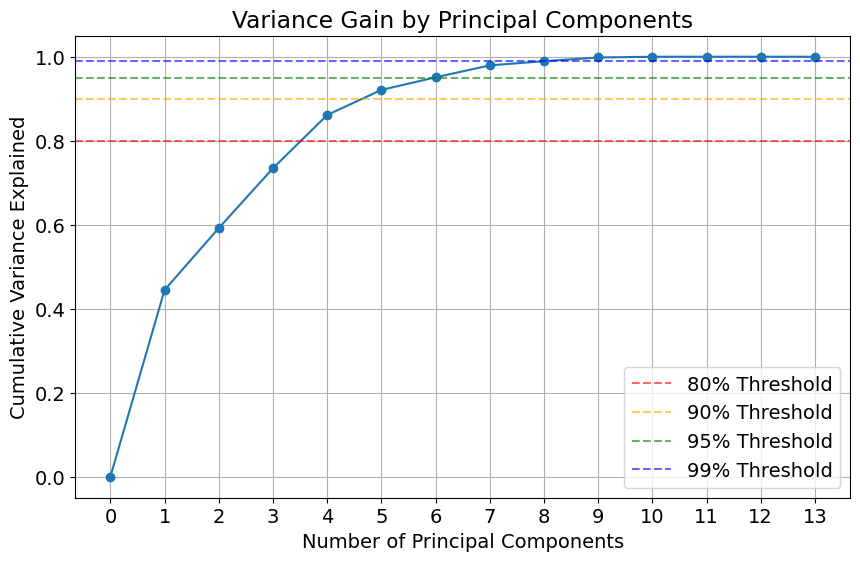

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Cumulative variance
cumvar = np.cumsum(explained_variance)
cumvar = np.insert(cumvar, 0, 0)

# X-axis values: 0 to num of components
x_vals = np.arange(len(cumvar))

# Plot
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)

plt.plot(x_vals, cumvar, marker='o')
plt.title('Variance Gain by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.xticks(x_vals)
plt.grid(True)

# Add variance thresholds
for thresh, color in zip([0.8, 0.9, 0.95, 0.99], ['red', 'orange', 'green', 'blue']):
    plt.axhline(y=thresh, color=color, linestyle='--', alpha=0.6, label=f'{int(thresh*100)}% Threshold')

plt.legend()
plt.show()


So we see 80% of the data can be explained by 3-4 PCS.

We also see 90%, 95%, and 99% variance can be explained by 5, 6, 8 PCs respectively.  



In [ ]:
# === Select top N features from Random Forest ===
TOP_N = 8  # You can change this to any number of top features you want
top_features = importances.head(TOP_N).index.tolist()
print(f"Top {TOP_N} features selected:", top_features)

# Create a new DataFrame with those features + target
df_selected = df[top_features + ['FIRE_START_DAY']]

# Save to CSV for modeling
df_selected.to_csv('/content/drive/My Drive/COMP560 FINAL PROJECT CODE/selected_rf_features.csv', index=False)
print("Saved selected features to 'selected_rf_features.csv'")


Top 8 features selected: ['MIN_TEMP', 'DAY_OF_YEAR', 'YEAR', 'MAX_TEMP', 'LAGGED_AVG_WIND_SPEED', 'WIND_TEMP_RATIO', 'DAY_OF_MONTH', 'AVG_WIND_SPEED']
Saved selected features to 'selected_rf_features.csv'
